In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
path = "/kaggle/input/datasets"

print(os.listdir(path))

['harudra125', 'kaustubhdikshit']


In [4]:
print(os.listdir("/kaggle/input/datasets/harudra125"))

['steel-defect-detection']


In [5]:
path = "/kaggle/input/datasets/harudra125/steel-defect-detection"

print(os.listdir(path))

['NEU-DET-MAN CNN']


In [6]:
path = "/kaggle/input/datasets/harudra125/steel-defect-detection/NEU-DET-MAN CNN"

print(os.listdir(path))

['validation', 'train']


In [7]:
train_path = os.path.join(path, 'train')
print(os.listdir(train_path))

['annotations', 'images']


In [8]:
images_path = os.path.join(train_path, 'images')
print(os.listdir(images_path))

['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']


In [9]:
# How many images we have for each class to know the bal/imbanced

train_path = os.path.join(path, 'train', 'images')

classes = os.listdir(train_path)

for cls in classes:
    class_path = os.path.join(train_path, cls)
#    print(class_path)
    print(f'{cls}: {len(os.listdir(class_path))} images')

inclusion: 240 images
scratches: 240 images
pitted_surface: 240 images
patches: 240 images
crazing: 240 images
rolled-in_scale: 240 images


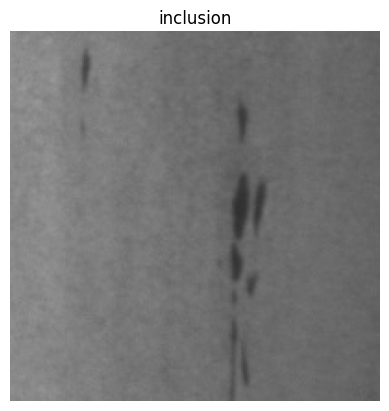

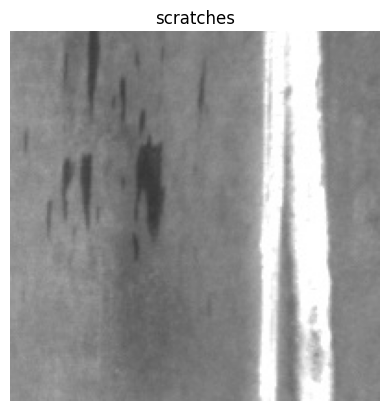

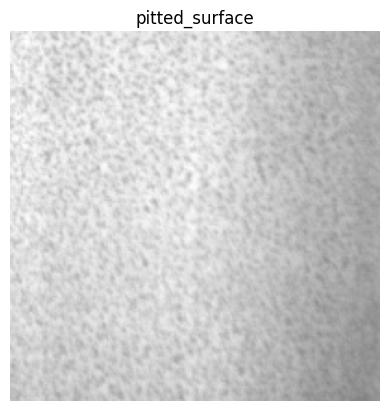

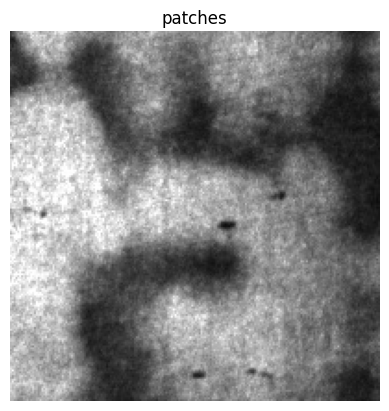

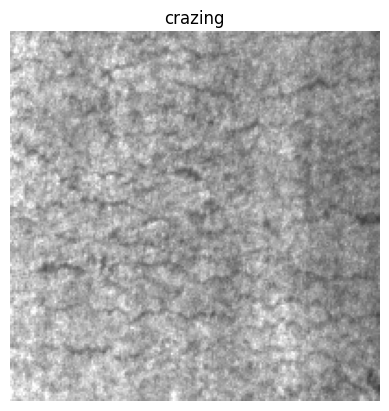

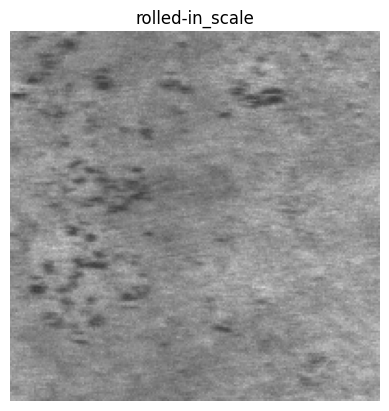

In [10]:
# sample image for each class

for cls in classes:
    class_path = os.path.join(train_path, cls)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')
    plt.show()

In [11]:
# Load All Images and Labels

rows = []
labels = []

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        #CNN requires all images to have the same size
        image = cv2.resize(image, (120, 120))/255.0

        rows.append(image)
        labels.append(cls)

In [12]:
print(len(rows))
print(len(labels))
print(rows[0].shape)

1440
1440
(120, 120, 3)


In [13]:
# CNN models (TensorFlow/Keras) work with NumPy arrays, not Python lists.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [14]:
encoder = LabelEncoder()

X = np.array(rows)
y = encoder.fit_transform(labels)

print(X.shape)
print(y.shape)
print(encoder.classes_)

(1440, 120, 120, 3)
(1440,)
['crazing' 'inclusion' 'patches' 'pitted_surface' 'rolled-in_scale'
 'scratches']


In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=23, stratify=y)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(1152, 120, 120, 3) (288, 120, 120, 3) (1152,) (288,)


In [16]:
# Transfer Learning

from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(120,120,3)
)

base_model.trainable = False

I0000 00:00:1787778447.302426      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787778447.305478      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
# Create New Model
from keras.models import Sequential
from keras.layers import Dense, Flatten

model_vgg = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

In [19]:
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,414 (58.39 MB)

 Trainable params: 590,726 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
model_vgg.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history_vgg = model_vgg.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
 3/36 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2569 - loss: 1.9395

I0000 00:00:1787778952.383066     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.8307 - loss: 0.5373 - val_accuracy: 0.9236 - val_loss: 0.2053
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9644 - loss: 0.1352 - val_accuracy: 0.9618 - val_loss: 0.1329
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9731 - loss: 0.0981 - val_accuracy: 0.9688 - val_loss: 0.0998
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9800 - loss: 0.0693 - val_accuracy: 0.9688 - val_loss: 0.0918
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9887 - loss: 0.0466 - val_accuracy: 0.9618 - val_loss: 0.1024


In [22]:
model_vgg.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9618 - loss: 0.1024


[0.10237520188093185, 0.9618055820465088]

In [23]:
pred = model_vgg.predict(x_test)

prediction = np.argmax(pred, axis=1)
prediction

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


array([5, 3, 5, 2, 5, 1, 4, 4, 0, 0, 1, 5, 0, 5, 0, 2, 4, 4, 5, 4, 2, 0,
       4, 0, 1, 5, 1, 0, 0, 0, 2, 1, 5, 4, 0, 5, 5, 2, 0, 0, 0, 3, 2, 2,
       5, 0, 3, 5, 4, 0, 0, 0, 1, 1, 0, 4, 3, 2, 2, 5, 1, 4, 0, 1, 2, 3,
       0, 1, 0, 5, 3, 3, 0, 2, 1, 4, 4, 2, 4, 4, 2, 3, 4, 5, 1, 3, 2, 1,
       0, 3, 5, 1, 2, 2, 5, 5, 2, 3, 5, 5, 3, 4, 4, 0, 1, 0, 3, 4, 0, 4,
       1, 2, 1, 0, 1, 3, 2, 0, 5, 4, 0, 0, 4, 4, 1, 5, 2, 5, 3, 2, 1, 5,
       0, 5, 3, 3, 5, 4, 1, 2, 3, 2, 4, 3, 1, 5, 5, 0, 3, 3, 0, 4, 1, 3,
       4, 4, 1, 1, 2, 2, 1, 3, 1, 1, 4, 3, 2, 4, 1, 2, 1, 5, 2, 3, 0, 2,
       4, 3, 1, 3, 4, 4, 3, 1, 0, 5, 5, 2, 1, 2, 3, 4, 2, 4, 2, 2, 1, 1,
       0, 1, 5, 3, 2, 3, 2, 1, 1, 2, 4, 1, 1, 1, 4, 0, 3, 1, 3, 5, 3, 0,
       4, 4, 5, 3, 5, 3, 1, 0, 3, 4, 5, 0, 2, 2, 0, 4, 1, 4, 1, 1, 0, 5,
       4, 4, 5, 5, 1, 2, 0, 2, 3, 5, 1, 4, 2, 1, 5, 3, 1, 5, 2, 3, 1, 2,
       3, 3, 1, 1, 0, 4, 5, 0, 1, 0, 2, 0, 0, 5, 3, 2, 0, 1, 0, 4, 3, 2,
       5, 0])

In [25]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


print(confusion_matrix(y_test, prediction))

print(classification_report(
    y_test,
    prediction,
    target_names=encoder.classes_
))

[[48  0  0  0  0  0]
 [ 0 48  0  0  0  0]
 [ 1  0 47  0  0  0]
 [ 1  4  0 43  0  0]
 [ 1  0  0  1 46  0]
 [ 0  3  0  0  0 45]]
                 precision    recall  f1-score   support

        crazing       0.94      1.00      0.97        48
      inclusion       0.87      1.00      0.93        48
        patches       1.00      0.98      0.99        48
 pitted_surface       0.98      0.90      0.93        48
rolled-in_scale       1.00      0.96      0.98        48
      scratches       1.00      0.94      0.97        48

       accuracy                           0.96       288
      macro avg       0.97      0.96      0.96       288
   weighted avg       0.97      0.96      0.96       288



In [26]:
# VGG16 Fine-tuning

for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [27]:
# Unfreeze last VGG16 block

base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [28]:
model_vgg.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_finetune = model_vgg.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.5408 - loss: 3.9882 - val_accuracy: 0.9097 - val_loss: 0.2435
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9418 - loss: 0.1598 - val_accuracy: 0.9653 - val_loss: 0.1311
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9635 - loss: 0.1259 - val_accuracy: 0.9618 - val_loss: 0.0958
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9575 - loss: 0.1179 - val_accuracy: 0.9722 - val_loss: 0.0890
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9913 - loss: 0.0279 - val_accuracy: 0.9792 - val_loss: 0.0424


In [30]:
model_vgg.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9792 - loss: 0.0424


[0.04236700385808945, 0.9791666865348816]

### Data Augmentation

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

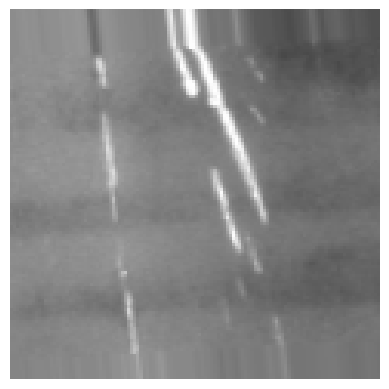

In [32]:
# Apply augmentation

image = x_train[0]

image = np.expand_dims(image, axis=0)

augmented = datagen.flow(image, batch_size=1)

aug_image = next(augmented)[0]

plt.imshow(aug_image)
plt.axis("off")
plt.show()

### YOLO Object Detection

In [33]:
print(os.listdir(path))

['validation', 'train']


In [34]:
print(os.listdir(os.path.join(path, "train")))

['annotations', 'images']


In [35]:
annotations_path = os.path.join(path, "train", "annotations")

print(os.listdir(annotations_path)[:5])

['patches_36.xml', 'inclusion_147.xml', 'crazing_200.xml', 'rolled-in_scale_32.xml', 'rolled-in_scale_61.xml']


In [36]:
# Check one XML

import xml.etree.ElementTree as ET

xml_path = os.path.join(
    annotations_path,
    "patches_36.xml"
)

tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    print("Class:", obj.find("name").text)

    bbox = obj.find("bndbox")

    print("xmin:", bbox.find("xmin").text)
    print("ymin:", bbox.find("ymin").text)
    print("xmax:", bbox.find("xmax").text)
    print("ymax:", bbox.find("ymax").text)

Class: patches
xmin: 16
ymin: 101
xmax: 70
ymax: 135
Class: patches
xmin: 109
ymin: 5
xmax: 164
ymax: 199


### Create YOLO class mapping

In [37]:
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

class_map = {name: i for i, name in enumerate(class_names)}

print(class_map)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


### Create YOLO folder structure

In [38]:
yolo_path = "/kaggle/working/steel_defect_yolo"

os.makedirs(os.path.join(yolo_path, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(yolo_path, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(yolo_path, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(yolo_path, "labels", "val"), exist_ok=True)

print("YOLO folders created")

YOLO folders created


In [39]:
import shutil

def convert_to_yolo(image_dir, annotation_dir, split):

    output_image_dir = os.path.join(yolo_path, "images", split)
    output_label_dir = os.path.join(yolo_path, "labels", split)

    for xml_file in os.listdir(annotation_dir):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(annotation_dir, xml_file)

        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_name = root.find("filename").text.strip()

        if not image_name.endswith(".jpg"):
            image_name += ".jpg"

        image_path = None

        for cls in os.listdir(image_dir):
            possible_path = os.path.join(image_dir, cls, image_name)

            if os.path.exists(possible_path):
                image_path = possible_path
                break

        # Skip XML if corresponding image doesn't exist
        if image_path is None:
            print("Skipped:", xml_file)
            continue

        image = cv2.imread(image_path)

        height, width = image.shape[:2]

        label_file = os.path.splitext(xml_file)[0] + ".txt"
        label_path = os.path.join(output_label_dir, label_file)

        with open(label_path, "w") as f:

            for obj in root.findall("object"):

                class_name = obj.find("name").text
                class_id = class_map[class_name]

                bbox = obj.find("bndbox")

                xmin = float(bbox.find("xmin").text)
                ymin = float(bbox.find("ymin").text)
                xmax = float(bbox.find("xmax").text)
                ymax = float(bbox.find("ymax").text)

                x_center = ((xmin + xmax) / 2) / width
                y_center = ((ymin + ymax) / 2) / height

                box_width = (xmax - xmin) / width
                box_height = (ymax - ymin) / height

                f.write(
                    f"{class_id} {x_center} {y_center} "
                    f"{box_width} {box_height}\n"
                )

        shutil.copy(image_path, output_image_dir)

In [54]:
train_images = os.path.join(path, "train", "images")
train_annotations = os.path.join(path, "train", "annotations")

val_images = os.path.join(path, "validation", "images")
val_annotations = os.path.join(path, "validation", "annotations")

convert_to_yolo(train_images, train_annotations, "train")
convert_to_yolo(val_images, val_annotations, "val")

print("XML to YOLO conversion completed")

Skipped: crazing_240.xml
XML to YOLO conversion completed


### Verify images and labels

In [55]:
print("Train images:", len(os.listdir(os.path.join(yolo_path, "images", "train"))))
print("Train labels:", len(os.listdir(os.path.join(yolo_path, "labels", "train"))))

print("Val images:", len(os.listdir(os.path.join(yolo_path, "images", "val"))))
print("Val labels:", len(os.listdir(os.path.join(yolo_path, "labels", "val"))))

Train images: 1439
Train labels: 1439
Val images: 360
Val labels: 360


### Create data.yaml

In [56]:
data_yaml = f"""
path: {yolo_path}

train: images/train
val: images/val

nc: 6

names:
  - crazing
  - inclusion
  - patches
  - pitted_surface
  - rolled-in_scale
  - scratches
"""

yaml_path = os.path.join(yolo_path, "data.yaml")

with open(yaml_path, "w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


### Install Ultralytics

In [44]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 4.2 MB/s eta 0:00:00


In [57]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

### Train YOLO11n

In [58]:
results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=320,
    batch=16
)

Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/steel_defect_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, n

### Test YOLO on a New Image

In [60]:
import os

print(os.listdir("/kaggle/working/steel_defect_yolo/images/val")[:10])

['inclusion_263.jpg', 'patches_263.jpg', 'pitted_surface_272.jpg', 'rolled-in_scale_289.jpg', 'rolled-in_scale_243.jpg', 'patches_281.jpg', 'pitted_surface_246.jpg', 'rolled-in_scale_294.jpg', 'crazing_297.jpg', 'rolled-in_scale_255.jpg']


In [62]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [63]:
results = model.predict(
    source="/kaggle/working/steel_defect_yolo/images/val/inclusion_263.jpg",
    conf=0.25,
    save=True
)


image 1/1 /kaggle/working/steel_defect_yolo/images/val/inclusion_263.jpg: 320x320 2 inclusions, 8.1ms
Speed: 0.9ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 320)
Results saved to /kaggle/working/runs/detect/predict-2


### YOLO image detection is working.

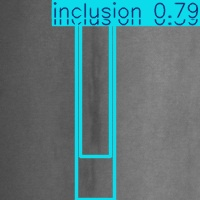

In [64]:
from IPython.display import Image, display

display(Image(
    filename="/kaggle/working/runs/detect/predict/inclusion_263.jpg"
))

### Evaluate YOLO Model

In [65]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/kaggle/working/steel_defect_yolo/data.yaml"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 536.1±344.7 MB/s, size: 14.6 KB)
val: Scanning /kaggle/working/steel_defect_yolo/labels/val.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 151.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.0it/s 2.9s<0.1s
                   all        360        854      0.552      0.657      0.653      0.329
               crazing         60        162      0.546      0.191      0.335      0.124
             inclusion         71        159      0.601      0.723      0.764      0.406
               patches         73        193      0.755      0.886      0.913      0.556
        pitted_surface         60         87      0.744       0.69      0.812      0.442
       rolled-in_scale   

### Predict on validation images

In [69]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

results = model.predict(
    source="/kaggle/working/steel_defect_yolo/images/val",
    conf=0.25,
    save=True
)


image 1/360 /kaggle/working/steel_defect_yolo/images/val/crazing_241.jpg: 320x320 (no detections), 11.4ms
image 2/360 /kaggle/working/steel_defect_yolo/images/val/crazing_242.jpg: 320x320 (no detections), 9.6ms
image 3/360 /kaggle/working/steel_defect_yolo/images/val/crazing_243.jpg: 320x320 (no detections), 9.7ms
image 4/360 /kaggle/working/steel_defect_yolo/images/val/crazing_244.jpg: 320x320 (no detections), 9.7ms
image 5/360 /kaggle/working/steel_defect_yolo/images/val/crazing_245.jpg: 320x320 (no detections), 10.0ms
image 6/360 /kaggle/working/steel_defect_yolo/images/val/crazing_246.jpg: 320x320 (no detections), 9.7ms
image 7/360 /kaggle/working/steel_defect_yolo/images/val/crazing_247.jpg: 320x320 1 crazing, 9.9ms
image 8/360 /kaggle/working/steel_defect_yolo/images/val/crazing_248.jpg: 320x320 (no detections), 9.6ms
image 9/360 /kaggle/working/steel_defect_yolo/images/val/crazing_249.jpg: 320x320 (no detections), 10.2ms
image 10/360 /kaggle/working/steel_defect_yolo/images/val

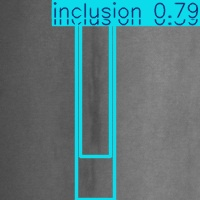

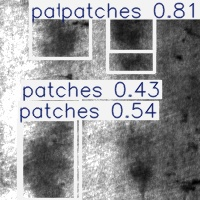

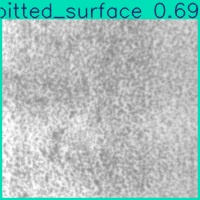

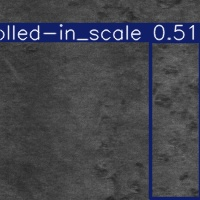

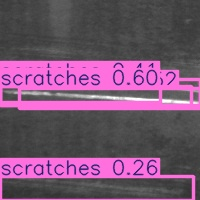

In [79]:
from IPython.display import Image, display
import os

pred_path = "/kaggle/working/runs/detect/predict-4"

for file in [
    "inclusion_263.jpg",
    "patches_250.jpg",
    "pitted_surface_250.jpg",
    "rolled-in_scale_250.jpg",
    "scratches_250.jpg"
]:
    display(Image(filename=os.path.join(pred_path, file)))